# Introducción

```{index} SQL
```

En este apartado vamos a ver como iteractuamos con bases de datos ## Enseñar a los agentes a recuperar y actualizar datos estructurados.

Los agentes obtienen un nivel de utilidad completamente nuevo al poder acceder y modificar datos privados y estructurados, como registros internos, sistemas de tickets o bases de datos de clientes.

A diferencia de los datos web públicos o las API, este tipo de información reside dentro de una organización y suele almacenarse en formatos estructurados que requieren una interacción precisa.

Si se le pregunta a un agente “¿Cuál es el estado del ticket n.° 9265?”, no puede buscarlo en la web, o al menos ahí será muy difícil encuentre la información solicitada. La respuesta probablemente se encuentre en una base de datos relacional o un CRM. De
igual manera, si el agente completa una tarea, debería actualizar el sistema correspondiente; no solo confirmar el éxito en el chat, sino escribir una nueva entrada en la base de datos. Los agentes que interactúan con datos estructurados pueden realizar trabajo real, no solo generar texto.

## Comprensión de las bases de datos

Existen muchos tipos de bases de datos que según la estructura de esos datos, y a grandes rasgos se pueden casificar como:

* **Las bases de datos relacionales** (por ejemplo, PostgreSQL, MySQL) almacenan datos en tablas con esquemas definidos, lo que resulta perfecto para interacciones de agentes que requieren consultas estructuradas.

* **Las bases de datos NoSQL** (por ejemplo, MongoDB) ofrecen flexibilidad, pero se utilizan con menos frecuencia para la integración directa de agentes.

* **Las bases de datos vectoriales** (por ejemplo, Chroma, Pinecone) almacenan incrustaciones para la búsqueda semántica, lo que permite la recuperación basada en similitud, una parte clave de muchos flujos de trabajo RAG (Recuperación-Generación Aumentada).

Pero en este apartado vamos a poner el enfoque en las bases de datos relacional, en las que se accede a la información mediante el lenguaje SQL

## text2SQL: Traduciendo el lenguaje a consultas
```{index} text2SQL
```

Los agentes pueden traducir lenguaje natural a SQL, una práctica conocida como `text2SQL`. Por ejemplo:

*Entrada*: “¿Cuántos usuarios se registraron esta semana?”

**Producción*: SELECT COUNT(*) FROM users WHERE signup_date >= ‘2025-07-01’

Esto requiere que el agente:

* Comprender los esquemas de bases de datos

* Manejar filtros y rangos de fechas

*  Evite consultas peligrosas (por ejemplo, accidentales DELETE)

Para evitar errores críticos, los agentes del mundo real deben estar protegidos con medidas de seguridad, incluida la validación de consultas y las aprobaciones humanas.

Como resumen de esta introducción, podemos decir que:

* La recuperación de datos estructurados permite a los agentes realizar tareas significativas dentro de sistemas privados.

*  Los agentes pueden leer y escribir datos utilizando SQL con medidas de seguridad implementadas.

*  Las bases de datos vectoriales permiten la búsqueda semántica, pero no son la única forma de realizar RAG.

* La combinación de fuentes de datos relacionales y vectoriales proporciona a los agentes capacidades de razonamiento más profundas y flexibles.

Los agentes más eficaces son aquellos que pueden integrarse con sistemas estructurados, tomar decisiones informadas y producir resultados que importan en contextos del mundo real.

Comenzamos este apartado viendo determinados aspectos de la base de datos sqlite para posteriormente ir avanzando en nivel de conocimientos hasta llegar a usar `sqlalchemy` que supone un nivel avanzado en el tratamiento de las bases de datos con python.

## sqlite
```{index} sqlite
```
`SQLite` es un sistema de gestión de bases de datos relacional muy ligero y ampliamente utilizado. A diferencia de otros sistemas como MySQL o PostgreSQL, SQLite no funciona como un servidor independiente, sino que está integrado directamente dentro de la aplicación que lo usa.

Esto significa que no requiere instalación ni configuración compleja: toda la base de datos se guarda en un único archivo en el sistema, lo que lo hace ideal para aplicaciones móviles, programas de escritorio o proyectos pequeños.

SQLite utiliza el lenguaje estándar SQL para realizar operaciones como crear tablas, insertar datos, consultarlos o modificarlos. A pesar de su simplicidad, es muy potente y cumple con gran parte del estándar SQL, incluyendo transacciones seguras.

En resumen, SQLite es una opción práctica cuando necesitas una base de datos rápida, sencilla y sin complicaciones de administración.





In [1]:
# Importamos sqlite (antes se debetener instalado db-sqlite3)
import sqlite3

Con esta esta herramienta podemos crear una base de datos en local, que por ejemplo se llame `employe.db`, de la siguiente manera:

In [2]:
connection = sqlite3.connect("employee.db")

Al ejecutar la instrucción anterior, podemos abservar que se ha creado un fichero denominado `employe.db` en la misma carpeta que donde está este fichero jupyter. Veamos a continuación la información que obtenemos con este objeto:

In [3]:
connection

Hasta esto momento lo que tenemos es una base de datos, pero sin tablas, a continuación creamos tres tablas que serán la base de futuros trabajos expositivos sobre esta materia.

In [4]:
table_creation_query="""
CREATE TABLE IF NOT EXISTS employees (
    emp_id INTEGER PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    hire_date TEXT NOT NULL,
    salary REAL NOT NULL
);
"""

table_creation_query2="""
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    phone TEXT
);
"""

table_creation_query3="""
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    amount REAL NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers (customer_id)
);

"""
# Creamos un objeto cursor
cursor=connection.cursor()
# generamos realmente la primera tabla
cursor.execute(table_creation_query)

# generamos realmente la segunda tabla
cursor.execute(table_creation_query2)

# generamos realmente la tercera tabla
cursor.execute(table_creation_query3)

Los esquemas UML generado con estas instrucciones son los siguientes:

![](../../img/esquemaUML.jpg)

A continuación procedemos a llenar las tablas con valores, para ello, lo primero que hacemos es crear las plantillas correspondientes:

In [5]:
#plantilla para employes
insert_query = """
INSERT INTO employees (emp_id, first_name, last_name, email, hire_date, salary)
VALUES (?, ?, ?, ?, ?, ?);
"""

# plantilla para customers
insert_query_customers = """
INSERT INTO customers (customer_id, first_name, last_name, email, phone)
VALUES (?, ?, ?, ?, ?);
"""

# plantilla para orders
insert_query_orders = """
INSERT INTO orders (order_id, customer_id, order_date, amount)
VALUES (?, ?, ?, ?);
"""

Ahora definimos realmente los datos que vamos a incluir

In [6]:
employee_data = [
    (1, "Sunny", "Savita", "sunny.sv@abc.com", "2023-06-01", 50000.00),
    (2, "Arhun", "Meheta", "arhun.m@gmail.com", "2022-04-15", 60000.00),
    (3, "Alice", "Johnson", "alice.johnson@jpg.com", "2021-09-30", 55000.00),
    (4, "Bob", "Brown", "bob.brown@uio.com", "2020-01-20", 45000.00),
    ]

customers_data = [
    (1, "John", "Doe", "john.doe@example.com", "1234567890"),
    (2, "Jane", "Smith", "jane.smith@example.com", "9876543210"),
    (3, "Emily", "Davis", "emily.davis@example.com", "4567891230"),
    (4, "Michael", "Brown", "michael.brown@example.com", "7894561230"),
]

orders_data = [
    (1, 1, "2023-12-01", 250.75),
    (2, 2, "2023-11-20", 150.50),
    (3, 3, "2023-11-25", 300.00),
    (4, 4, "2023-12-02", 450.00),
]

Ahora incorporamos realmente los datos:

In [7]:
cursor.executemany(insert_query,employee_data)
connection.commit()

In [8]:

cursor.executemany(insert_query_customers,customers_data)

cursor.executemany(insert_query_orders,orders_data)

connection.commit()

In [9]:
# Veamos el contenido de los registros
cursor.execute("select * from employees;")
for row in cursor.fetchall():
    print(row)

(1, 'Sunny', 'Savita', 'sunny.sv@abc.com', '2023-06-01', 50000.0)
(2, 'Arhun', 'Meheta', 'arhun.m@gmail.com', '2022-04-15', 60000.0)
(3, 'Alice', 'Johnson', 'alice.johnson@jpg.com', '2021-09-30', 55000.0)
(4, 'Bob', 'Brown', 'bob.brown@uio.com', '2020-01-20', 45000.0)


In [10]:
cursor.execute("select first_name from employees where salary > 50000.0;")
cursor.fetchall()

[('Arhun',), ('Alice',)]

In [11]:
cursor.execute("SELECT name FROM sqlite_master WHERE type = 'table';")
cursor.fetchall()

[('employees',), ('customers',), ('sqlite_sequence',), ('orders',)]

## LLM con Groq
```{index} Groq
```

Hasta estos momentos, se ha utilizado una gestión de base de datos de modo tradicional. En lo que sigue, introducimos el modelo LLM con Groq, pues ademá de ser generoso con la parte gratuita, nos va a permitir desarrollar los conceptos fundamentales perseguidoes en este apartado. 

Comenzamos leyendo la api key que nos proporciona esta LLM (se puede obtener, previa identificación en https://console.groq.com/keys)

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"]= GROQ_API_KEY

from langchain_groq import ChatGroq
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [13]:
# Probamos el modelo anterior
llm.invoke("Buenos días, como estás?").content

'**Buenos días**\n\nMe alegra que hayas empezado el día con un saludo tan amable. Estoy aquí para ayudarte en lo que necesites, ya sea responder a tus preguntas, proporcionar información o simplemente charlar un rato.\n\n**¿Cómo puedo ayudarte hoy?**\n\n¿Tienes alguna pregunta o tema en particular que te gustaría discutir? Estoy aquí para escucharte y ayudarte en lo que pueda.'

```{index} SQLDatabase
```
Preparamos a continuación todo lo necesario para utilizar modelos y herramientas que nos proporciona LangChain. Comenzamos con el usos de una herramienta que nos proporciona la comunidad de LangChain, como es SQLDatabase.

In [14]:
from langchain_community.utilities import SQLDatabase
db = SQLDatabase.from_uri("sqlite:///employee.db")

print("Dialect:", db.dialect)
print("Tablas en la base de datos:", db.get_usable_table_names())

Dialect: sqlite
Tablas en la base de datos: ['customers', 'employees', 'orders']


In [15]:
query_result = db.run("SELECT * FROM employees ;")
print("Registros que hay en la BD employees: \n", query_result)

Registros que hay en la BD employees: 
 [(1, 'Sunny', 'Savita', 'sunny.sv@abc.com', '2023-06-01', 50000.0), (2, 'Arhun', 'Meheta', 'arhun.m@gmail.com', '2022-04-15', 60000.0), (3, 'Alice', 'Johnson', 'alice.johnson@jpg.com', '2021-09-30', 55000.0), (4, 'Bob', 'Brown', 'bob.brown@uio.com', '2020-01-20', 45000.0)]


```{index} SQLDatabaseToolkit
```

Utilizar este tipo de herramientas nos proporciona la ventaja de que facilitan una serie de herramientas (Tools) que nos facilitan mucho el trabajo. En este caso concreto vamos a ver las herramientas que la comunidad de LangChain nos ofrece para el trabajo con bases de datos (Ver el siguiente enlace: https://reference.langchain.com/python/langchain-community/agent_toolkits/sql/toolkit/SQLDatabaseToolkit).

In [16]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit=SQLDatabaseToolkit(db=db,llm=llm)
tools=toolkit.get_tools()
tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D10BB45C0>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D10BB45C0>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D10BB45C0>),
 QuerySQLCheckerTool(description='Use this tool to 

In [17]:
for tool in tools:
    print(tool.name)

sql_db_query
sql_db_schema
sql_db_list_tables
sql_db_query_checker


In [18]:
list_tables_tool = next((tool for tool in tools if tool.name == "sql_db_list_tables"), None)
list_tables_tool

ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D10BB45C0>)

In [19]:
get_schema_tool = next((tool for tool in tools if tool.name == "sql_db_schema"), None)
get_schema_tool

InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x0000023D10BB45C0>)

Con los objetos creados de esta manera, podemos obtener, por ejemplo,  una lista de tablas existentes en la base de datos o el esquema de una determinada tabla de la base de datos

In [20]:
print(list_tables_tool.invoke(""))

customers, employees, orders


In [21]:
print(get_schema_tool.invoke("employees"))


CREATE TABLE employees (
	emp_id INTEGER, 
	first_name TEXT NOT NULL, 
	last_name TEXT NOT NULL, 
	email TEXT NOT NULL, 
	hire_date TEXT NOT NULL, 
	salary REAL NOT NULL, 
	PRIMARY KEY (emp_id), 
	UNIQUE (email)
)

/*
3 rows from employees table:
emp_id	first_name	last_name	email	hire_date	salary
1	Sunny	Savita	sunny.sv@abc.com	2023-06-01	50000.0
2	Arhun	Meheta	arhun.m@gmail.com	2022-04-15	60000.0
3	Alice	Johnson	alice.johnson@jpg.com	2021-09-30	55000.0
*/


El esquema que seguiremos en esta exposición es el siguiente:

![](../../img/esquemaTool.png)

Con todo este potencial que nos ofrecen las Tools mostradas anteriormente, procedemos a crear una Tool personalizada que nos puede servir bien para desarrollos posteriores

In [22]:
from langchain_core.tools import tool
@tool
def db_query_tool(query: str) -> str:
    """
    Execute a SQL query against the database and return the result.
    If the query is invalid or returns no result, an error message will be returned.
    In case of an error, the user is advised to rewrite the query and try again.
    """
    result = db.run_no_throw(query)
    if not result:
        return "Error: Query fallado. Escribe la query de nuevo e inténtalo de nuevo."
    return result

Probemos la Tool o herramienta anterior para ver como funciona

In [23]:
print(db_query_tool.invoke("SELECT * FROM Employees LIMIT 5;"))

[(1, 'Sunny', 'Savita', 'sunny.sv@abc.com', '2023-06-01', 50000.0), (2, 'Arhun', 'Meheta', 'arhun.m@gmail.com', '2022-04-15', 60000.0), (3, 'Alice', 'Johnson', 'alice.johnson@jpg.com', '2021-09-30', 55000.0), (4, 'Bob', 'Brown', 'bob.brown@uio.com', '2020-01-20', 45000.0)]


Creamos a continuación una clase que nos va a servir para obtener una respuesta estructurada, es decir una respuesta con un formato que es el que nosotros queremos ([ver este apartado](templates)). Con esto vamos a asegurar que el resultado final del LLM es una cadena de tipo string. 

In [24]:
from pydantic import BaseModel, Field

class SubmitFinalAnswer(BaseModel):
    """Submit the final answer to the user based on the query results."""
    final_answer: str = Field(..., description="The final answer to the user")

También hay que definir el [estado del agente](estado) que lo que hace es mantener los mensajes que fluyen a lo largo de todo el trabajo del agente. Lo hacemos a continuación 

In [25]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

A continuación voy a definir el denominado systemMessage

In [28]:
from langchain_core.prompts import ChatPromptTemplate
import rich

query_check_system = """You are a SQL expert with a strong attention to detail.
Double check the SQLite query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

You will call the appropriate tool to execute the query after running this check."""

query_check_prompt = ChatPromptTemplate.from_messages([("system", query_check_system), ("placeholder", "{messages}")])

query_check = query_check_prompt | llm.bind_tools([db_query_tool])

rich.print(query_check.invoke({"messages": [("user", "SELECT * FROM Employees LIMIT 5;")]}))

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': '6t6cpk8hy',
                'function': {
                    'arguments': '{"query":"SELECT * FROM Employees LIMIT 5;"}',
                    'name': 'db_query_tool'
                },
                'type': 'function'
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 36,
            'prompt_tokens': 884,
            'total_tokens': 920,
            'completion_time': 0.081354721,
            'completion_tokens_details': None,
            'prompt_time': 0.039182011,
            'prompt_tokens_details': None,
            'queue_time': 0.593818716,
            'total_time': 0.120536732
        },
        'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct',
        'system_fingerprint': 'fp_37da608fc1',
        'service_tier': 'on_demand',
        'finish_reason': 'tool_calls',
        'logprobs': None,
        'model_provider': 'groq'
    },
    id='lc_run--019dfe21-66be-7bb3-a674-fb46064f5a00-0',
    tool_calls=[
        {
            'name': 'db_query_tool',
            'args': {'query': 'SELECT * FROM Employees LIMIT 5;'},
            'id': '6t6cpk8hy',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 884, 'output_tokens': 36, 'total_tokens': 920}
)

Como puede verse en la salida anterior, realmente se está llamando a la Tool creada previamente.

Veamos otro ejemplo muy parecido al anterior, pero en lugar de poner * en la consulta pongo +. Observar en la salida que el parámetro que se pasa a la Tool de consulta a la base de datos es correcto y ha cambiado el signo + por el signo *.

In [29]:
rich.print(query_check.invoke({"messages": [("user", "SELECT + FROM Employees LIMIT 5;")]}))

AIMessage(
    content="The provided SQL query seems to have a syntax error. The SELECT statement is missing a column or * to 
specify what columns to select.\n\nHere's a rewritten query:\n\n```sql\nSELECT * FROM Employees LIMIT 
5;\n```\n\nLet's execute the corrected query:\n\n",
    additional_kwargs={
        'tool_calls': [
            {
                'id': 'cwhvhj1sr',
                'function': {
                    'arguments': '{"query":"SELECT * FROM Employees LIMIT 5;"}',
                    'name': 'db_query_tool'
                },
                'type': 'function'
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 86,
            'prompt_tokens': 884,
            'total_tokens': 970,
            'completion_time': 0.194753462,
            'completion_tokens_details': None,
            'prompt_time': 0.044126381,
            'prompt_tokens_details': None,
            'queue_time': 0.500836991,
            'total_time': 0.238879843
        },
        'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct',
        'system_fingerprint': 'fp_2f97044c6d',
        'service_tier': 'on_demand',
        'finish_reason': 'tool_calls',
        'logprobs': None,
        'model_provider': 'groq'
    },
    id='lc_run--019dfe4b-c014-7990-b130-e9e75971bbf4-0',
    tool_calls=[
        {
            'name': 'db_query_tool',
            'args': {'query': 'SELECT * FROM Employees LIMIT 5;'},
            'id': 'cwhvhj1sr',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 884, 'output_tokens': 86, 'total_tokens': 970}
)

Vamos ahora a generar otro prompt system, de la siguiente manera

In [30]:
query_gen_system = """You are a SQL expert with a strong attention to detail.

Given an input question, output a syntactically correct SQLite query to run, then look at the results of the query and return the answer.

DO NOT call any tool besides SubmitFinalAnswer to submit the final answer.

When generating the query:

Output the SQL query that answers the input question without a tool call.

Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 5 results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.

If you get an error while executing a query, rewrite the query and try again.

If you get an empty result set, you should try to rewrite the query to get a non-empty result set.
NEVER make stuff up if you don't have enough information to answer the query... just say you don't have enough information.

If you have enough information to answer the input question, simply invoke the appropriate tool to submit the final answer to the user.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database. Do not return any sql query except answer."""


query_gen_prompt = ChatPromptTemplate.from_messages([("system", query_gen_system), ("placeholder", "{messages}")])

query_gen = query_gen_prompt | llm.bind_tools([SubmitFinalAnswer])

Y a continuación procedemos a definir la funciones que son la base de los nodos que posteriormente vamos a generar

In [32]:
from typing import Annotated, Literal
from langchain_core.messages import AIMessage
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import AnyMessage, add_messages
from typing import Any
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks
from langgraph.prebuilt import ToolNode

In [33]:
def first_tool_call(state:State)->dict[str,list[AIMessage]]:
    return{"messages": [AIMessage(content="",tool_calls=[{"name":"sql_db_list_tables","args":{},"id":"tool_abcd123"}])]}

In [34]:
def handle_tool_error(state:State) -> dict:
    error = state.get("error") 
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
        ToolMessage(content=f"Error: {repr(error)}\n please fix your mistakes.",tool_call_id=tc["id"],)
        for tc in tool_calls
        ]
    }
def create_tool_node_with_fallback(tools: list) -> RunnableWithFallbacks[Any, dict]:
    return ToolNode(tools).with_fallbacks([RunnableLambda(handle_tool_error)], exception_key="error")

In [35]:
def query_gen_node(state: State):
    message = query_gen.invoke(state)

    # Sometimes, the LLM will hallucinate and call the wrong tool. We need to catch this and return an error message.
    tool_messages = []
    if message.tool_calls:
        for tc in message.tool_calls:
            if tc["name"] != "SubmitFinalAnswer":
                tool_messages.append(
                    ToolMessage(
                        content=f"Error: The wrong tool was called: {tc['name']}. Please fix your mistakes. Remember to only call SubmitFinalAnswer to submit the final answer. Generated queries should be outputted WITHOUT a tool call.",
                        tool_call_id=tc["id"],
                    )
                )
    else:
        tool_messages = []
    return {"messages": [message] + tool_messages}

In [36]:
def should_continue(state: State) -> Literal[END, "correct_query", "query_gen"]:
    messages = state["messages"]
    last_message = messages[-1]
    if getattr(last_message, "tool_calls", None):
        return END
    if last_message.content.startswith("Error:"):
        return "query_gen"
    else:
        return "correct_query"

In [37]:
def model_check_query(state: State) -> dict[str, list[AIMessage]]:
    """
    Use this tool to double-check if your query is correct before executing it.
    """
    return {"messages": [query_check.invoke({"messages": [state["messages"][-1]]})]}

Ahora ya tenemos todas las funciones definidas para poder generar el grafo

In [38]:
workflow = StateGraph(State)

In [39]:
# creamos los nodos
workflow.add_node("first_tool_call",first_tool_call)
workflow.add_node("list_tables_tool", create_tool_node_with_fallback([list_tables_tool]))
workflow.add_node("get_schema_tool", create_tool_node_with_fallback([get_schema_tool]))
model_get_schema = llm.bind_tools([get_schema_tool])
workflow.add_node("model_get_schema",lambda state: {"messages": [model_get_schema.invoke(state["messages"])],},)
workflow.add_node("query_gen", query_gen_node)
workflow.add_node("correct_query", model_check_query)
workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))

In [40]:
workflow.add_edge(START, "first_tool_call")
workflow.add_edge("first_tool_call", "list_tables_tool")
workflow.add_edge("list_tables_tool", "model_get_schema")
workflow.add_edge("model_get_schema", "get_schema_tool")
workflow.add_edge("get_schema_tool", "query_gen")
workflow.add_conditional_edges("query_gen",should_continue,)
workflow.add_edge("correct_query", "execute_query")
workflow.add_edge("execute_query", "query_gen")

In [41]:
app = workflow.compile()

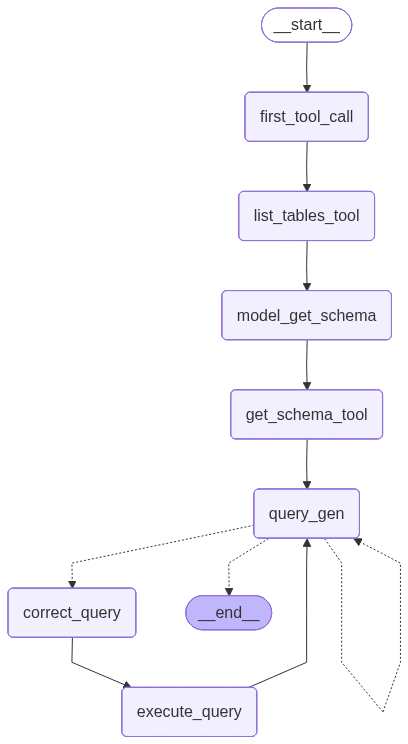

In [42]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

Probamos a continuación el agente que acabamos de crear con LagGraph

In [43]:
query={"messages": [("user", "Tell me name of the employee who's salary is more than 30000?")]}
response=app.invoke(query)
response["messages"][-1].tool_calls[0]["args"]["final_answer"]

'Arhun Meheta, Alice Johnson, Sunny Savita'

In [44]:
query={"messages": [("user", "Tell me about all the orders")]}
response = app.invoke(query)

response["messages"][-1].tool_calls[0]["args"]["final_answer"]

'The orders are as follows: \nOrder 1: Order ID - 1, Customer ID - 1, Order Date - 2023-12-01, Total - 250.75 \nOrder 2: Order ID - 2, Customer ID - 2, Order Date - 2023-11-20, Total - 150.5 \nOrder 3: Order ID - 3, Customer ID - 3, Order Date - 2023-11-25, Total - 300.0 \nOrder 4: Order ID - 4, Customer ID - 4, Order Date - 2023-12-02, Total - 450.0'

In [46]:
query={"messages": [("user", "Show the phone numbers of customers whose last name is 'Smith'?")]}
response = app.invoke(query)
response["messages"][-1].tool_calls[0]["args"]["final_answer"]

"SELECT phone FROM customers WHERE last_name = 'Smith' LIMIT 5;"

https://www.youtube.com/watch?v=gcRSQblTwPw&t=724s

https://github.com/sunnysavita10/langgraph-end-to-end/blob/main/agent_based_rag/sql_agent_with_langgraph.ipynb

## Utilización de SQLAlchemy
```{index} SQLAlchemy
```

SQLAlchemy es una librería de Python que permite interactuar con bases de datos relacionales (como SQLite, PostgreSQL, MySQL o SQL Server) de forma segura y eficiente, tanto usando SQL “nativo” como a través de un ORM (Object‑Relational Mapper).

Su idea central es que puedas trabajar con tablas y filas como clases y objetos de Python, en lugar de escribir solo cadenas de SQL, lo que hace el código más limpio, mantenible y portable entre motores de base de datos.

Para entender este apartado, no es necesario que el lector conozca al detalle el uso de esta librería, pero para quien esté interesado en su uso, puede consultar los siguientes enlaces:

* <a href="https://www.sqlalchemy.org/" target="_blank">Sitio oficial de SQLAchemy</a>

* <a href="https://4geeks.com/es/lesson/todo-lo-necesario-para-empezar-usar-sqlalchemy" target="_blank">Todo lo que necesitas saber de SQLAlchemy</a>

* <a href="https://j2logo.com/python/sqlalchemy-tutorial-de-python-sqlalchemy-guia-de-inicio/"> SQLAlchemy. Tutorial de Python SQLAlchemy </a>